# EDA del dataset modelable a 10 segundos

Este notebook analiza el dataset ya unificado y remuestreado a 10 segundos.

El objetivo es revisar visualmente la evolución temporal de `LT411` y de las principales variables de proceso antes de crear las variables del modelo.

En este punto se define también el split temporal inicial:

- Día 1: entrenamiento
- Día 2: validación
- Día 3: test y análisis de posible anomalía

Este notebook no entrena modelos. Solo sirve para entender la dinámica temporal del proceso y preparar el paso posterior de feature engineering.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Cargamos el dataset modelable a 10 segundos

df = pd.read_csv("../data/data_limpio/dataset_modelable_10s.csv")

df["Time"] = pd.to_datetime(df["Time"])

df.head()

,Time,LT411,SP_LT411,LV411,DT412,INT_P101,FQC400_1,SP_VAPOR,FV400_1,PT442,SP_PT442,PV442,TT413,TT415,LT426,SP_LT426,ACCION_PCT02,FT428,PIT410,PIT414
0,2021-11-05 08:00:00,58.142360,60.0,100.0,1229.492151,58.408563,3054.785938,69.0,59.5,0.154167,0.14,0.0,80.976565,81.82292,50.439814,50.0,18.861438,6.266928,0.326085,0.579514
1,2021-11-05 08:00:10,57.962962,60.0,100.0,1229.049451,58.272569,3052.526001,69.0,59.5,0.154282,0.14,0.0,80.954863,81.81424,50.422452,50.0,19.102801,6.293403,0.326181,0.579456
2,2021-11-05 08:00:20,57.323494,60.0,100.0,1229.088501,58.234953,3038.494727,69.0,59.5,0.154225,0.14,0.0,80.946182,81.81424,50.434027,50.0,19.315793,6.325521,0.326403,0.579051
3,2021-11-05 08:00:30,57.335069,60.0,100.0,1228.762976,58.463541,3031.794189,69.0,59.5,0.154282,0.14,0.0,80.946182,81.81424,50.422452,50.0,19.470506,6.357205,0.326340,0.578588
4,2021-11-05 08:00:40,57.835647,60.0,100.0,1229.453088,58.159721,3036.406226,69.0,59.5,0.154485,0.14,0.0,80.946182,81.81424,50.428239,50.0,19.712129,6.391927,0.326403,0.578125


In [4]:
# Revisamos la frecuencia temporal del dataset

df["delta_time"] = df["Time"].diff()

print("Frecuencia más común:", df["delta_time"].mode()[0])
print("Frecuencia mínima:", df["delta_time"].min())
print("Frecuencia máxima:", df["delta_time"].max())

df = df.drop(columns="delta_time")

Frecuencia más común: 0 days 00:00:10
Frecuencia mínima: 0 days 00:00:10
Frecuencia máxima: 0 days 00:00:10


## Evolución general de LT411

Se representa la evolución temporal de `LT411`, que será la variable target del sensor virtual.

El objetivo es revisar si la señal tiene continuidad, variabilidad suficiente y posibles zonas anómalas antes de entrenar modelos.

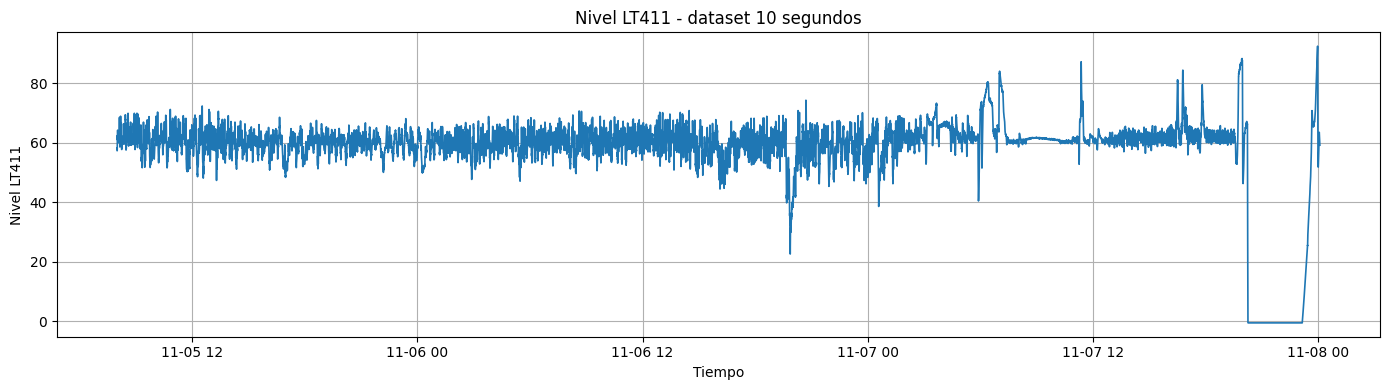

In [5]:
# Gráfico general de LT411

plt.figure(figsize=(14, 4))
plt.plot(df["Time"], df["LT411"], linewidth=1.2)

plt.title("Nivel LT411 - dataset 10 segundos")
plt.xlabel("Tiempo")
plt.ylabel("Nivel LT411")
plt.grid(True)
plt.tight_layout()
plt.show()

## Relación entre LT411 y LV411

Se compara `LT411` con `LV411` para entender visualmente la relación entre el nivel medido y la válvula de control asociada al lazo de nivel.

`LV411` puede ser muy informativa, pero no se usará en el Modelo A porque introduce riesgo de leakage al estar directamente relacionada con el lazo cerrado de control de `LT411`.

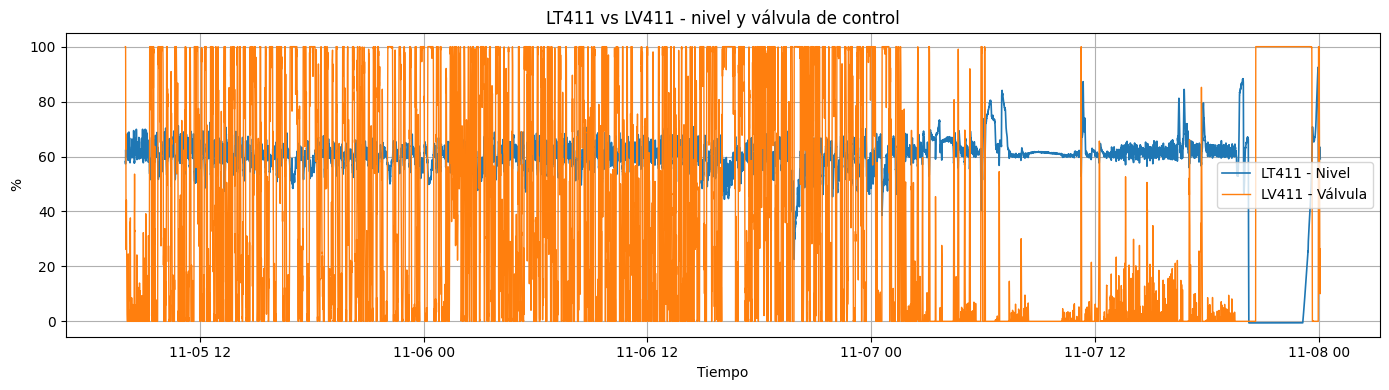

In [6]:
# Gráfico de LT411 frente a LV411

plt.figure(figsize=(14, 4))

plt.plot(df["Time"], df["LT411"], linewidth=1.2, label="LT411 - Nivel")
plt.plot(df["Time"], df["LV411"], linewidth=1.0, label="LV411 - Válvula")

plt.title("LT411 vs LV411 - nivel y válvula de control")
plt.xlabel("Tiempo")
plt.ylabel("%")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Creamos una columna con la fecha para separar los días

df["fecha"] = df["Time"].dt.date

df["fecha"].value_counts().sort_index()

fecha
2021-11-05    5760
2021-11-06    8640
2021-11-07    8640
2021-11-08      30
Name: count, dtype: int64

## Definición del split temporal

El proyecto se plantea como un problema temporal, por lo que no se utiliza split aleatorio.

Se define el siguiente reparto inicial:

- Día 1: entrenamiento
- Día 2: validación
- Día 3: test y análisis de comportamiento anómalo

El Día 3 no se usará para entrenar el Modelo A porque contiene la zona sospechosa de ensuciamiento/parada del sensor.

In [8]:
# Definimos cortes temporales iniciales para train, validación y test

inicio_train = pd.Timestamp("2021-11-05 08:00:00")
fin_train = pd.Timestamp("2021-11-06 07:59:59")

inicio_valid = pd.Timestamp("2021-11-06 08:00:00")
fin_valid = pd.Timestamp("2021-11-07 07:59:59")

inicio_test = pd.Timestamp("2021-11-07 08:00:00")
fin_test = df["Time"].max()

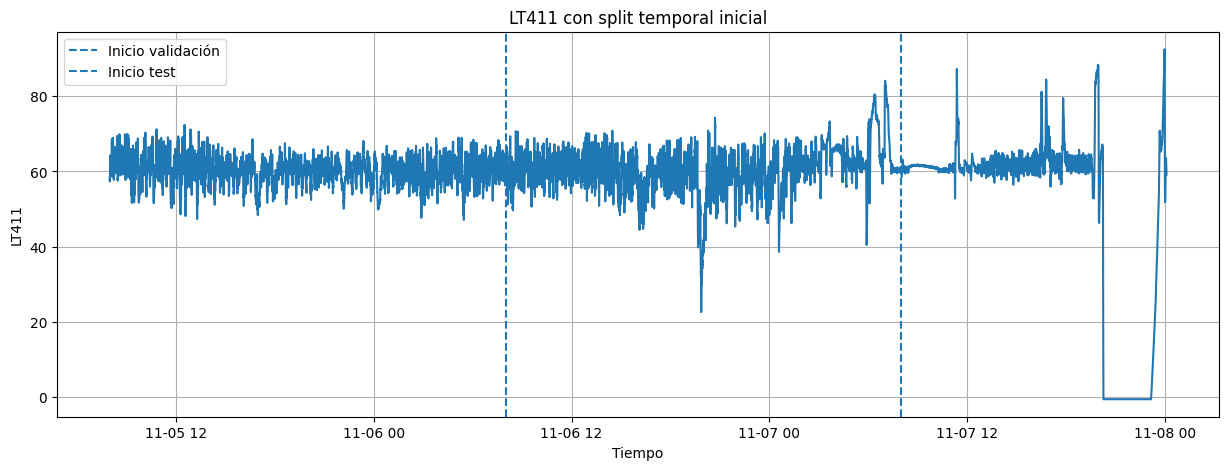

In [9]:
# Graficamos LT411 marcando train, validación y test

plt.figure(figsize=(15, 5))
plt.plot(df["Time"], df["LT411"])

plt.axvline(inicio_valid, linestyle="--", label="Inicio validación")
plt.axvline(inicio_test, linestyle="--", label="Inicio test")

plt.title("LT411 con split temporal inicial")
plt.xlabel("Tiempo")
plt.ylabel("LT411")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
# Asignamos cada fila a train, validación o test

df["bloque"] = "sin_asignar"

df.loc[(df["Time"] >= inicio_train) & (df["Time"] <= fin_train), "bloque"] = "train"
df.loc[(df["Time"] >= inicio_valid) & (df["Time"] <= fin_valid), "bloque"] = "validacion"
df.loc[(df["Time"] >= inicio_test) & (df["Time"] <= fin_test), "bloque"] = "test"

df["bloque"].value_counts()

bloque
train         8640
validacion    8640
test          5790
Name: count, dtype: int64

In [11]:
# Revisamos inicio, fin y número de filas por bloque

df.groupby("bloque").agg(
    inicio=("Time", "min"),
    fin=("Time", "max"),
    filas=("Time", "count")
)

,inicio,fin,filas
bloque,,,
test,2021-11-07 08:00:00,2021-11-08 00:04:50,5790
train,2021-11-05 08:00:00,2021-11-06 07:59:50,8640
validacion,2021-11-06 08:00:00,2021-11-07 07:59:50,8640


In [12]:
# Revisamos estadísticas de LT411 por bloque

df.groupby("bloque")["LT411"].describe()

,count,mean,std,min,25%,50%,75%,max
bloque,,,,,,,,
test,5790.0,50.143939,25.263527,-0.578704,59.401041,61.203703,62.467447,92.491317
train,8640.0,59.809870,3.617674,47.094907,57.580294,60.128761,62.161457,72.375578
validacion,8640.0,60.305748,6.168719,22.586805,57.209200,60.692997,63.545283,84.079861


## Lectura inicial por bloques

El bloque de entrenamiento presenta una señal más estable y se usa como base limpia inicial.

El bloque de validación mantiene dinámica de proceso, pero incorpora perturbaciones más marcadas.

El bloque de test contiene el comportamiento más crítico del proyecto, con caída de `LT411` y posible ensuciamiento/parada. Por esta razón se reserva para evaluación y análisis de anomalía, no para entrenamiento.

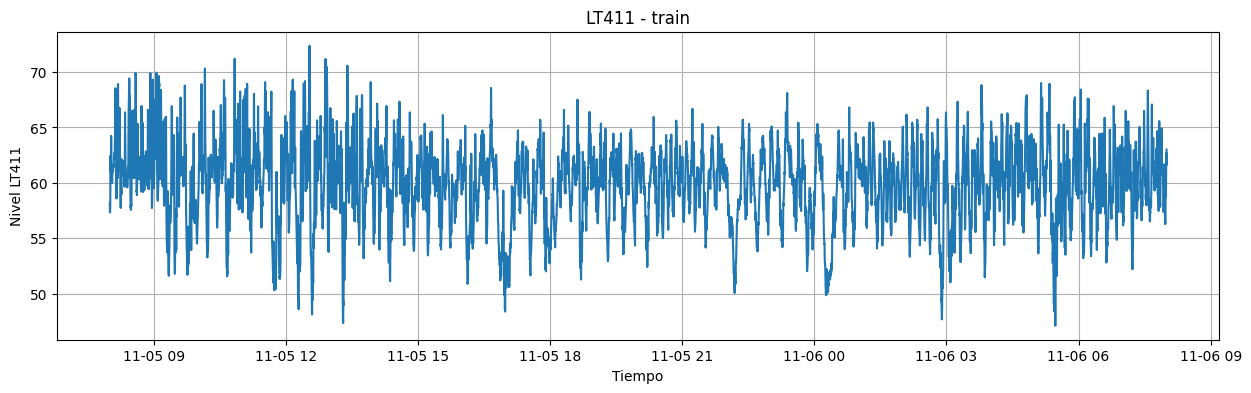

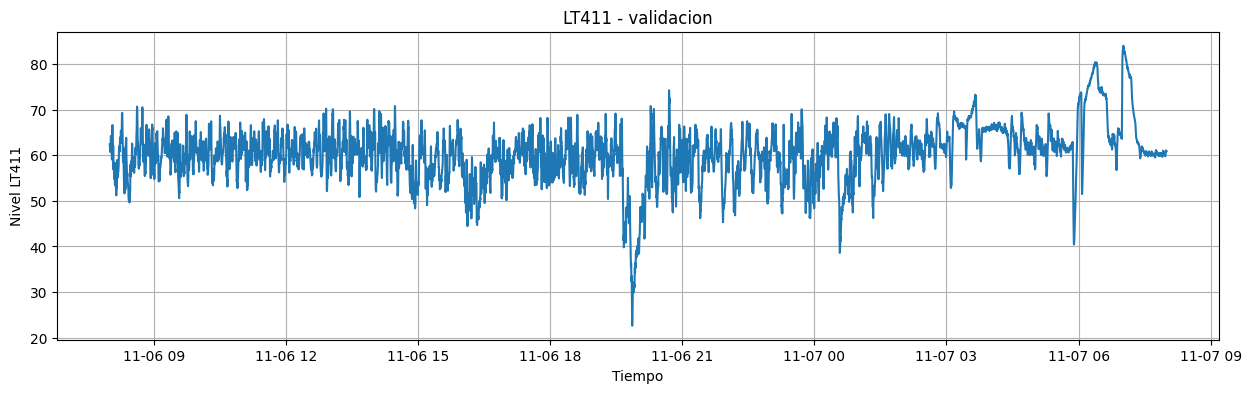

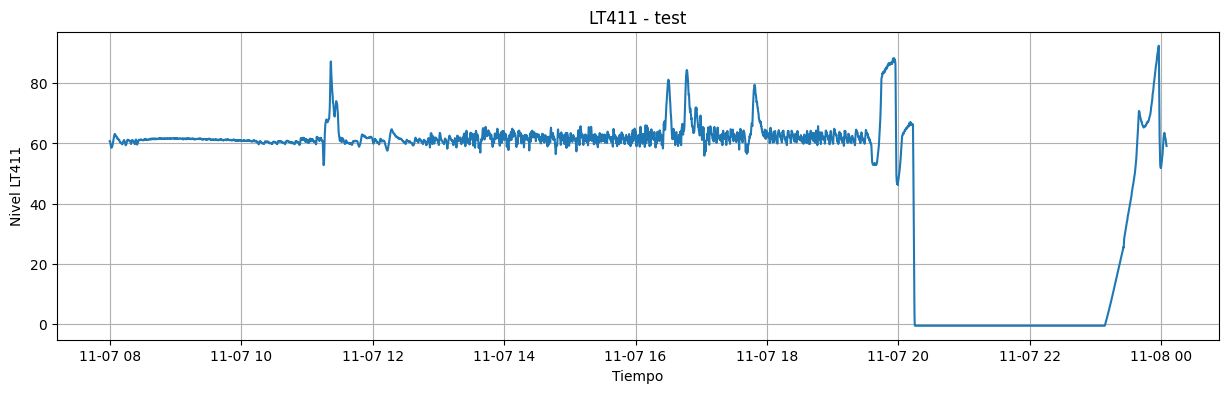

In [13]:
# Graficamos LT411 separando train, validación y test

for bloque in ["train", "validacion", "test"]:
    datos_bloque = df[df["bloque"] == bloque]

    plt.figure(figsize=(15, 4))
    plt.plot(datos_bloque["Time"], datos_bloque["LT411"])
    plt.title("LT411 - " + bloque)
    plt.xlabel("Tiempo")
    plt.ylabel("Nivel LT411")
    plt.grid(True)
    plt.show()

In [14]:
# Definimos variables principales para revisión visual

variables_revision = [
    "LT411",
    "PIT410",
    "PIT414",
    "TT413",
    "TT415",
    "DT412",
    "INT_P101",
    "FQC400_1",
    "PT442",
    "FT428",
    "LT426"
]

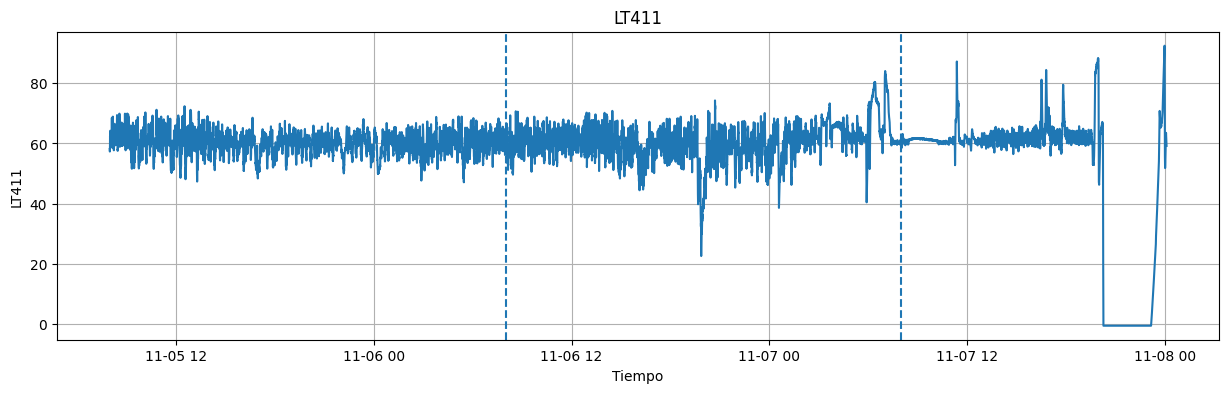

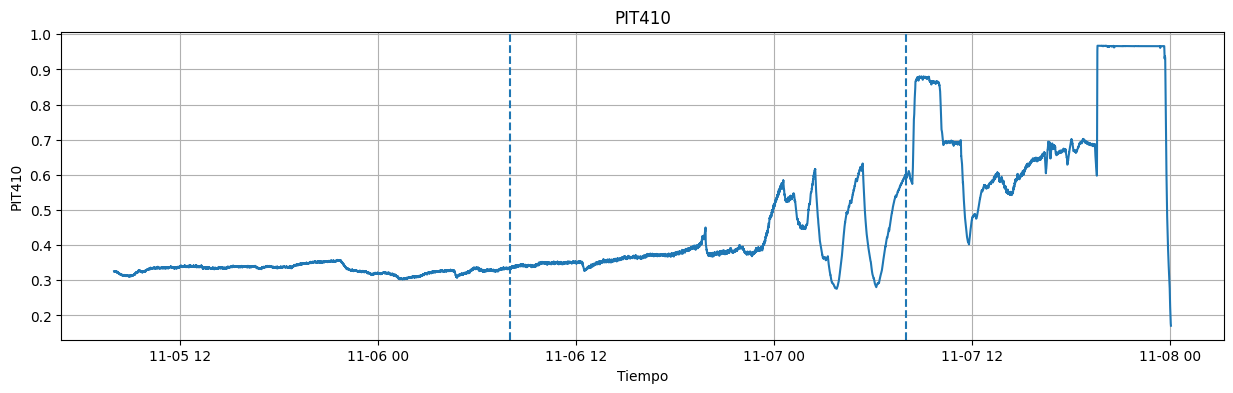

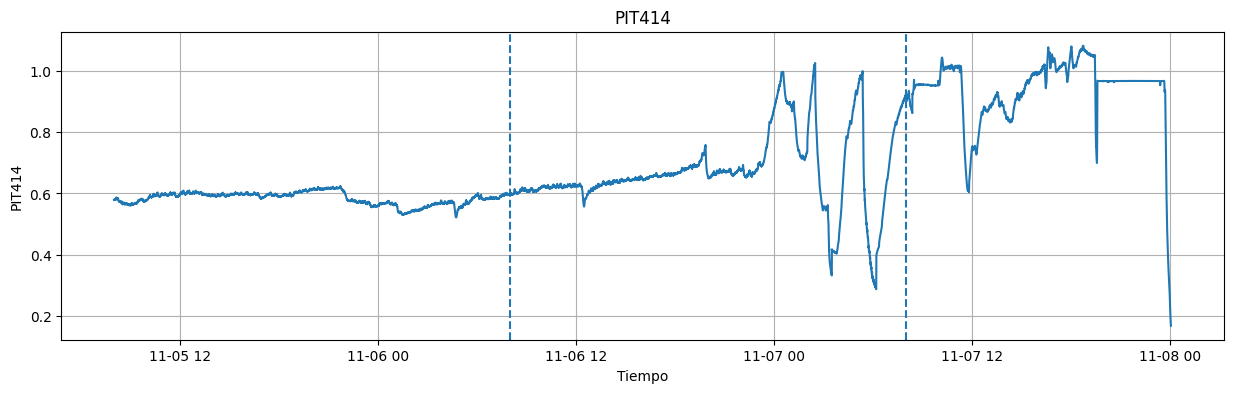

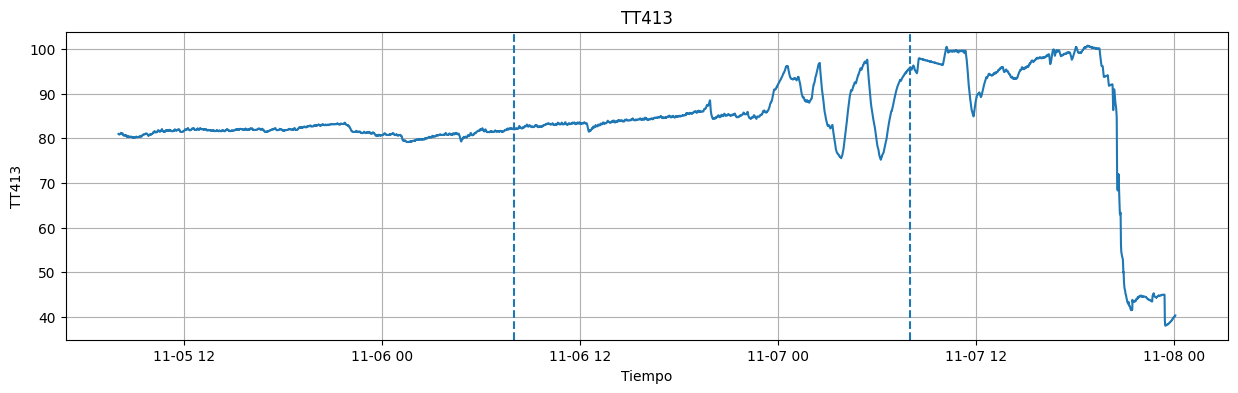

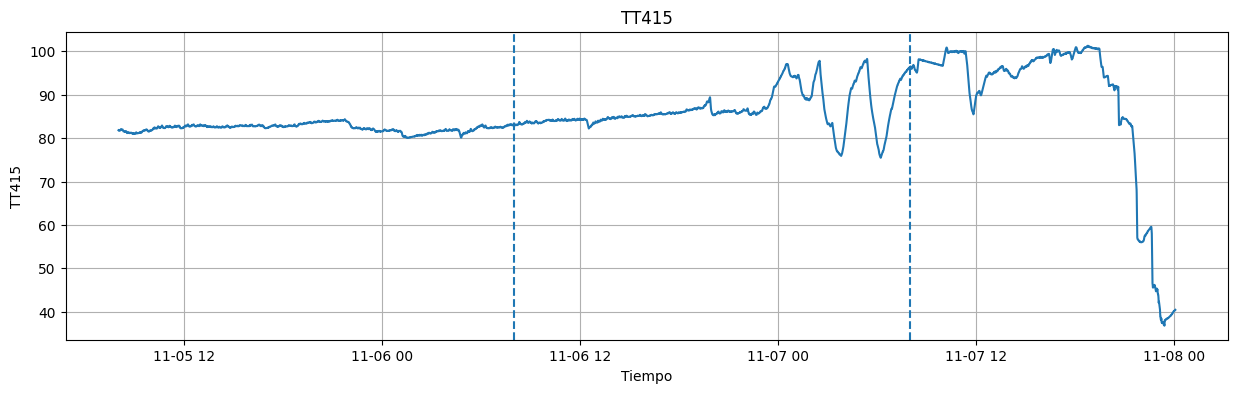

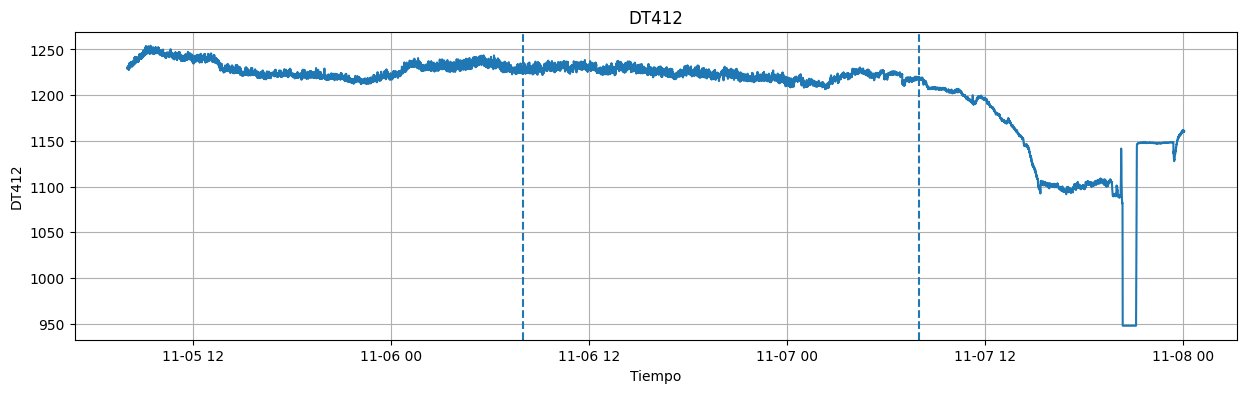

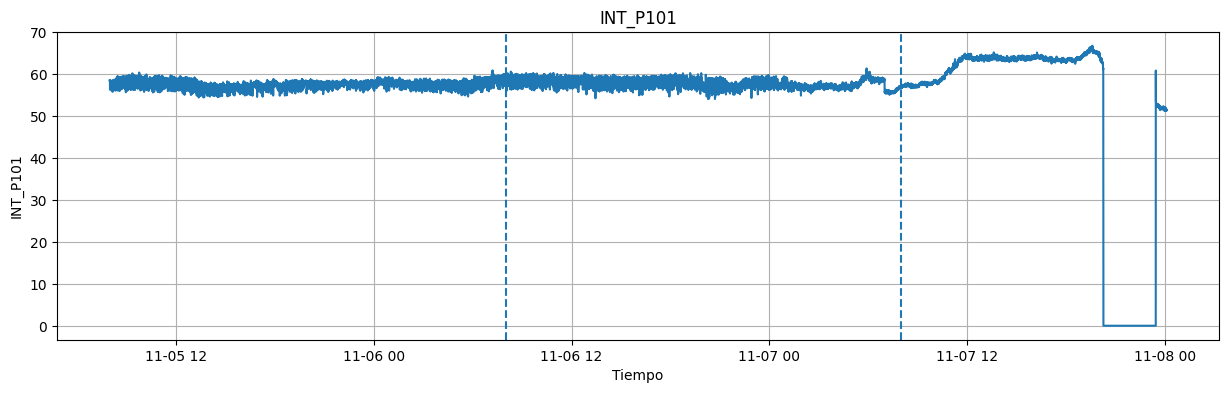

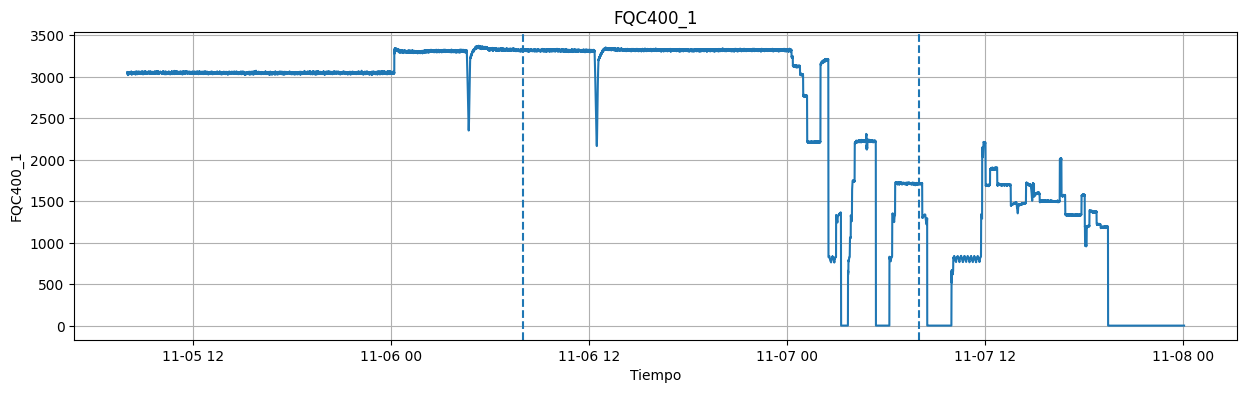

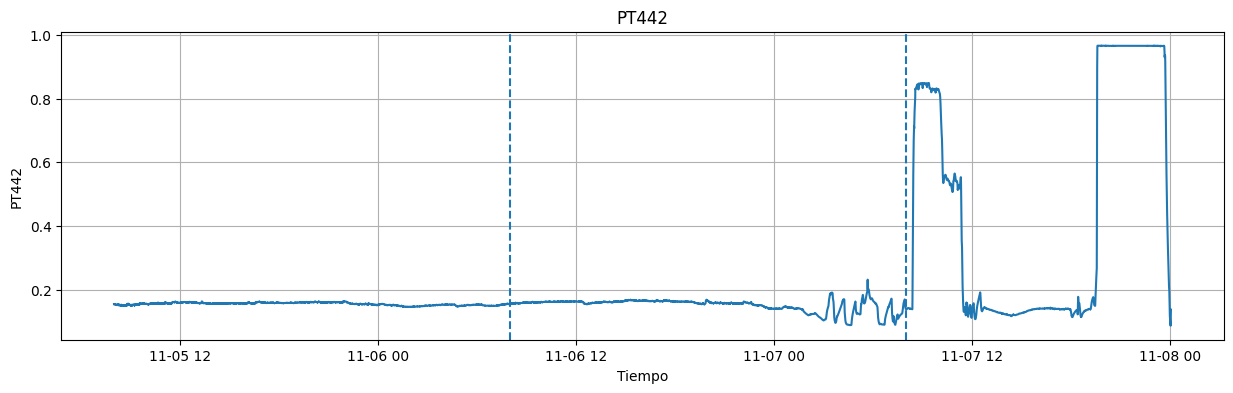

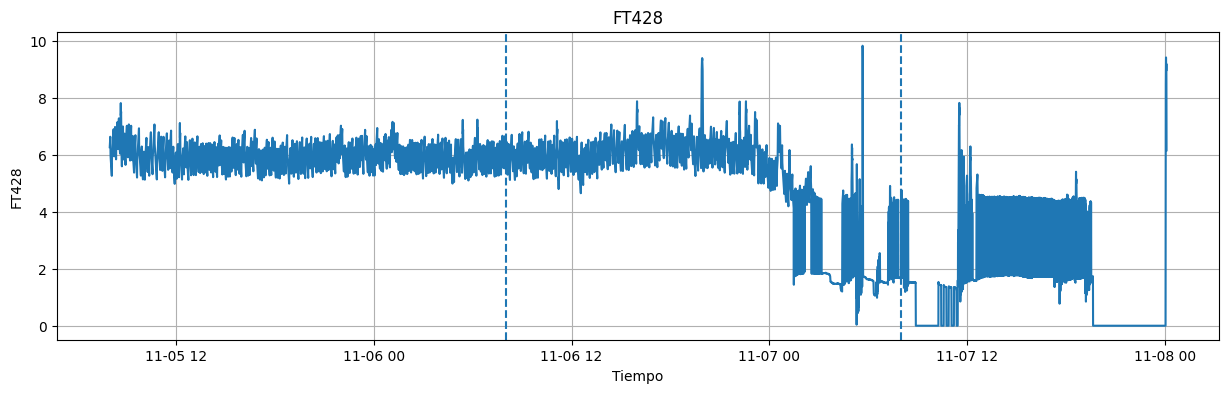

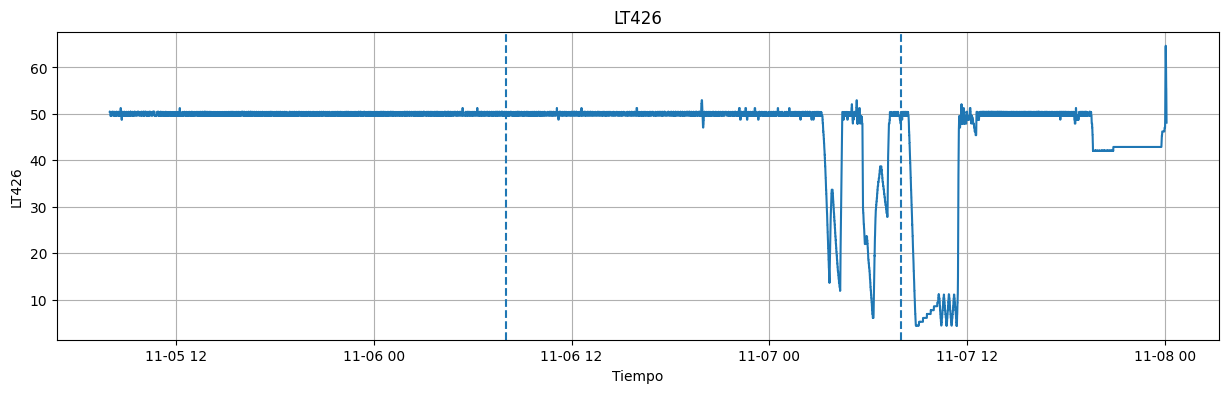

In [15]:
# Graficamos variables clave para revisar comportamiento temporal

for variable in variables_revision:
    plt.figure(figsize=(15, 4))
    plt.plot(df["Time"], df[variable])
    plt.axvline(inicio_valid, linestyle="--")
    plt.axvline(inicio_test, linestyle="--")
    plt.title(variable)
    plt.xlabel("Tiempo")
    plt.ylabel(variable)
    plt.grid(True)
    plt.show()

## Nota sobre FQC400_1

La variable `FQC400_1` contiene valores negativos físicamente imposibles para un caudal real de vapor.

En limpieza se ha conservado la señal original para mantener la trazabilidad del dato y no romper la continuidad temporal.

La corrección se realizará en el notebook de feature engineering mediante:

- `FQC400_1_corr`: señal corregida con valores negativos llevados a 0.
- `FQC400_1_negativo_flag`: indicador de valores negativos en la señal original.

De esta forma se mantiene la señal original y se ofrece al modelo una versión físicamente más coherente.

In [16]:
# Revisamos valores negativos en FQC400_1

print("Valores negativos en FQC400_1:", (df["FQC400_1"] < 0).sum())
print("Valor mínimo de FQC400_1:", df["FQC400_1"].min())

Valores negativos en FQC400_1: 61
Valor mínimo de FQC400_1: -0.8061619043350214


In [17]:
# Localizamos valores bajos de LT411 en test

df_test = df[df["bloque"] == "test"].copy()

df_test[df_test["LT411"] < 20][["Time", "LT411"]].head(20)

,Time,LT411
21687,2021-11-07 20:14:30,12.138310
21688,2021-11-07 20:14:40,4.470486
21689,2021-11-07 20:14:50,0.836227
21690,2021-11-07 20:15:00,-0.465856
21691,2021-11-07 20:15:10,-0.578704
21692,2021-11-07 20:15:20,-0.578704
21693,2021-11-07 20:15:30,-0.578704
21694,2021-11-07 20:15:40,-0.578704
21695,2021-11-07 20:15:50,-0.578704
21696,2021-11-07 20:16:00,-0.578704


In [18]:
# Localizamos el mínimo de LT411 en test

df_test.loc[df_test["LT411"].idxmin(), ["Time", "LT411"]]

Time     2021-11-07 20:15:10
LT411              -0.578704
Name: 21691, dtype: object

## Conclusiones del EDA a 10 segundos

El dataset modelable a 10 segundos conserva la dinámica principal de `LT411` y permite reducir el volumen de datos respecto a la frecuencia original de 1 segundo.

El split temporal queda definido como:

- Día 1: train
- Día 2: validación
- Día 3: test

El Día 3 presenta el comportamiento más crítico y se reserva para evaluar la capacidad del sensor virtual de detectar desviaciones entre el nivel medido y el nivel esperado.

`LV411` se mantiene como variable de análisis exploratorio, pero no se usará en el Modelo A por riesgo de leakage asociado al lazo cerrado de control.

`FQC400_1` conserva valores negativos en esta fase para mantener la trazabilidad. Su corrección se realizará en feature engineering.

El siguiente paso será crear las variables del Modelo A limpio, evitando `LV411`, `SP_LT411` y cualquier variable derivada de `LT411` como entrada del modelo.